# Energy, Bandwidth, and Aspect Ratio Sweeps

This notebook presents the combined results of two parameter sweeps that probe the operating range of diffractive cascades:

1. **Bandwidth vs. Energy** — how efficiency degrades as the illumination bandwidth increases, across different X-ray energies  
2. **Aspect Ratio (Thickness) vs. Energy** — how efficiency depends on the element thickness (and hence aspect ratio) at each energy

Both sweeps compare the optimized cascade against a conventional Fresnel zone plate, demonstrating the cascade's advantage in tolerating larger bandwidths and lower aspect ratios.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

from src.util import width_central_peak

In [3]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

## Load sweep data

Load results from both the bandwidth-energy sweep and the thickness-energy (aspect ratio) sweep. The efficiency arrays are extracted for both the optimized cascades and the FZP baseline.

In [4]:
path = repo_root / "paper_data"

bw_results = np.load(path / "bandwidth_energy_sweep_results.npz", allow_pickle=True)
bw_params = np.load(path / "bandwidth_energy_sweep_params.npy", allow_pickle=True).item()
bw_sweep_arrs = np.load(path / "bandwidth_energy_sweep_sweep_arrays.npy", allow_pickle=True).item()

ar_results = np.load(path / "thickness_energy_sweep_results.npz", allow_pickle=True)
ar_params = np.load(path / "thickness_energy_sweep_params.npy", allow_pickle=True).item()
ar_sweep_arrs = np.load(path / "thickness_energy_sweep_sweep_arrays.npy", allow_pickle=True).item()

In [5]:
bw_opt_intensities = bw_results["opt_intensities"]
bw_opt_efficiencies = bw_results["opt_efficiencies"].T

bw_fzp_intensities = bw_results["fzp_intensities"]
bw_fzp_efficiencies = bw_results["fzp_efficiencies"].T

bw_opt_params = bw_params["opt_params_template"]

bandwidths = bw_sweep_arrs["bandwidths"]
bw_energies = bw_sweep_arrs["energies"]

ar_opt_intensities = ar_results["opt_intensities"]
ar_opt_efficiencies = ar_results["opt_efficiencies"].T

ar_fzp_intensities = ar_results["fzp_intensities"]
ar_fzp_efficiencies = ar_results["fzp_efficiencies"].T

ar_opt_params = ar_params["opt_params_template"]

thicknesses = ar_sweep_arrs["thicknesses"]
ar_energies = ar_sweep_arrs["energies"]

energies = ar_energies

In [6]:
# recompute the efficiencies to exclude very wide focal spots
for i in range(len(bandwidths)):
    for j in range(len(energies)):

        Nx = bw_params['Nx']

        opt_intensity = bw_opt_intensities[i, j]
        fzp_intensity = bw_fzp_intensities[i, j]

        opt_width = width_central_peak(opt_intensity, 1e-2)
        fzp_width = width_central_peak(fzp_intensity, 1e-2)

        opt_efficiency = np.sum(opt_intensity[Nx//2 - opt_width//2 : Nx//2 + opt_width//2]) / Nx
        fzp_efficiency = np.sum(fzp_intensity[Nx//2 - fzp_width//2 : Nx//2 + fzp_width//2]) / Nx

        if opt_width > Nx / 10:
            opt_efficiency = 1 / Nx
        if fzp_width > Nx / 10:
            fzp_efficiency = 1 / Nx

        bw_opt_efficiencies[j, i] = opt_efficiency
        bw_fzp_efficiencies[j, i] = fzp_efficiency

In [7]:
# recompute the efficiencies to exclude very wide focal spots
for i in range(len(thicknesses)):
    for j in range(len(energies)):

        Nx = bw_params['Nx']

        opt_intensity = ar_opt_intensities[i, j]
        fzp_intensity = ar_fzp_intensities[i, j]

        opt_width = width_central_peak(opt_intensity, 1e-2)
        fzp_width = width_central_peak(fzp_intensity, 1e-2)

        opt_efficiency = np.sum(opt_intensity[Nx//2 - opt_width//2 : Nx//2 + opt_width//2]) / Nx
        fzp_efficiency = np.sum(fzp_intensity[Nx//2 - fzp_width//2 : Nx//2 + fzp_width//2]) / Nx

        if opt_width > Nx / 10:
            opt_efficiency = 1 / Nx
        if fzp_width > Nx / 10:
            fzp_efficiency = 1 / Nx

        ar_opt_efficiencies[j, i] = opt_efficiency
        ar_fzp_efficiencies[j, i] = fzp_efficiency

In [8]:
max_eff = max([bw_opt_efficiencies.max(), ar_opt_efficiencies.max()])

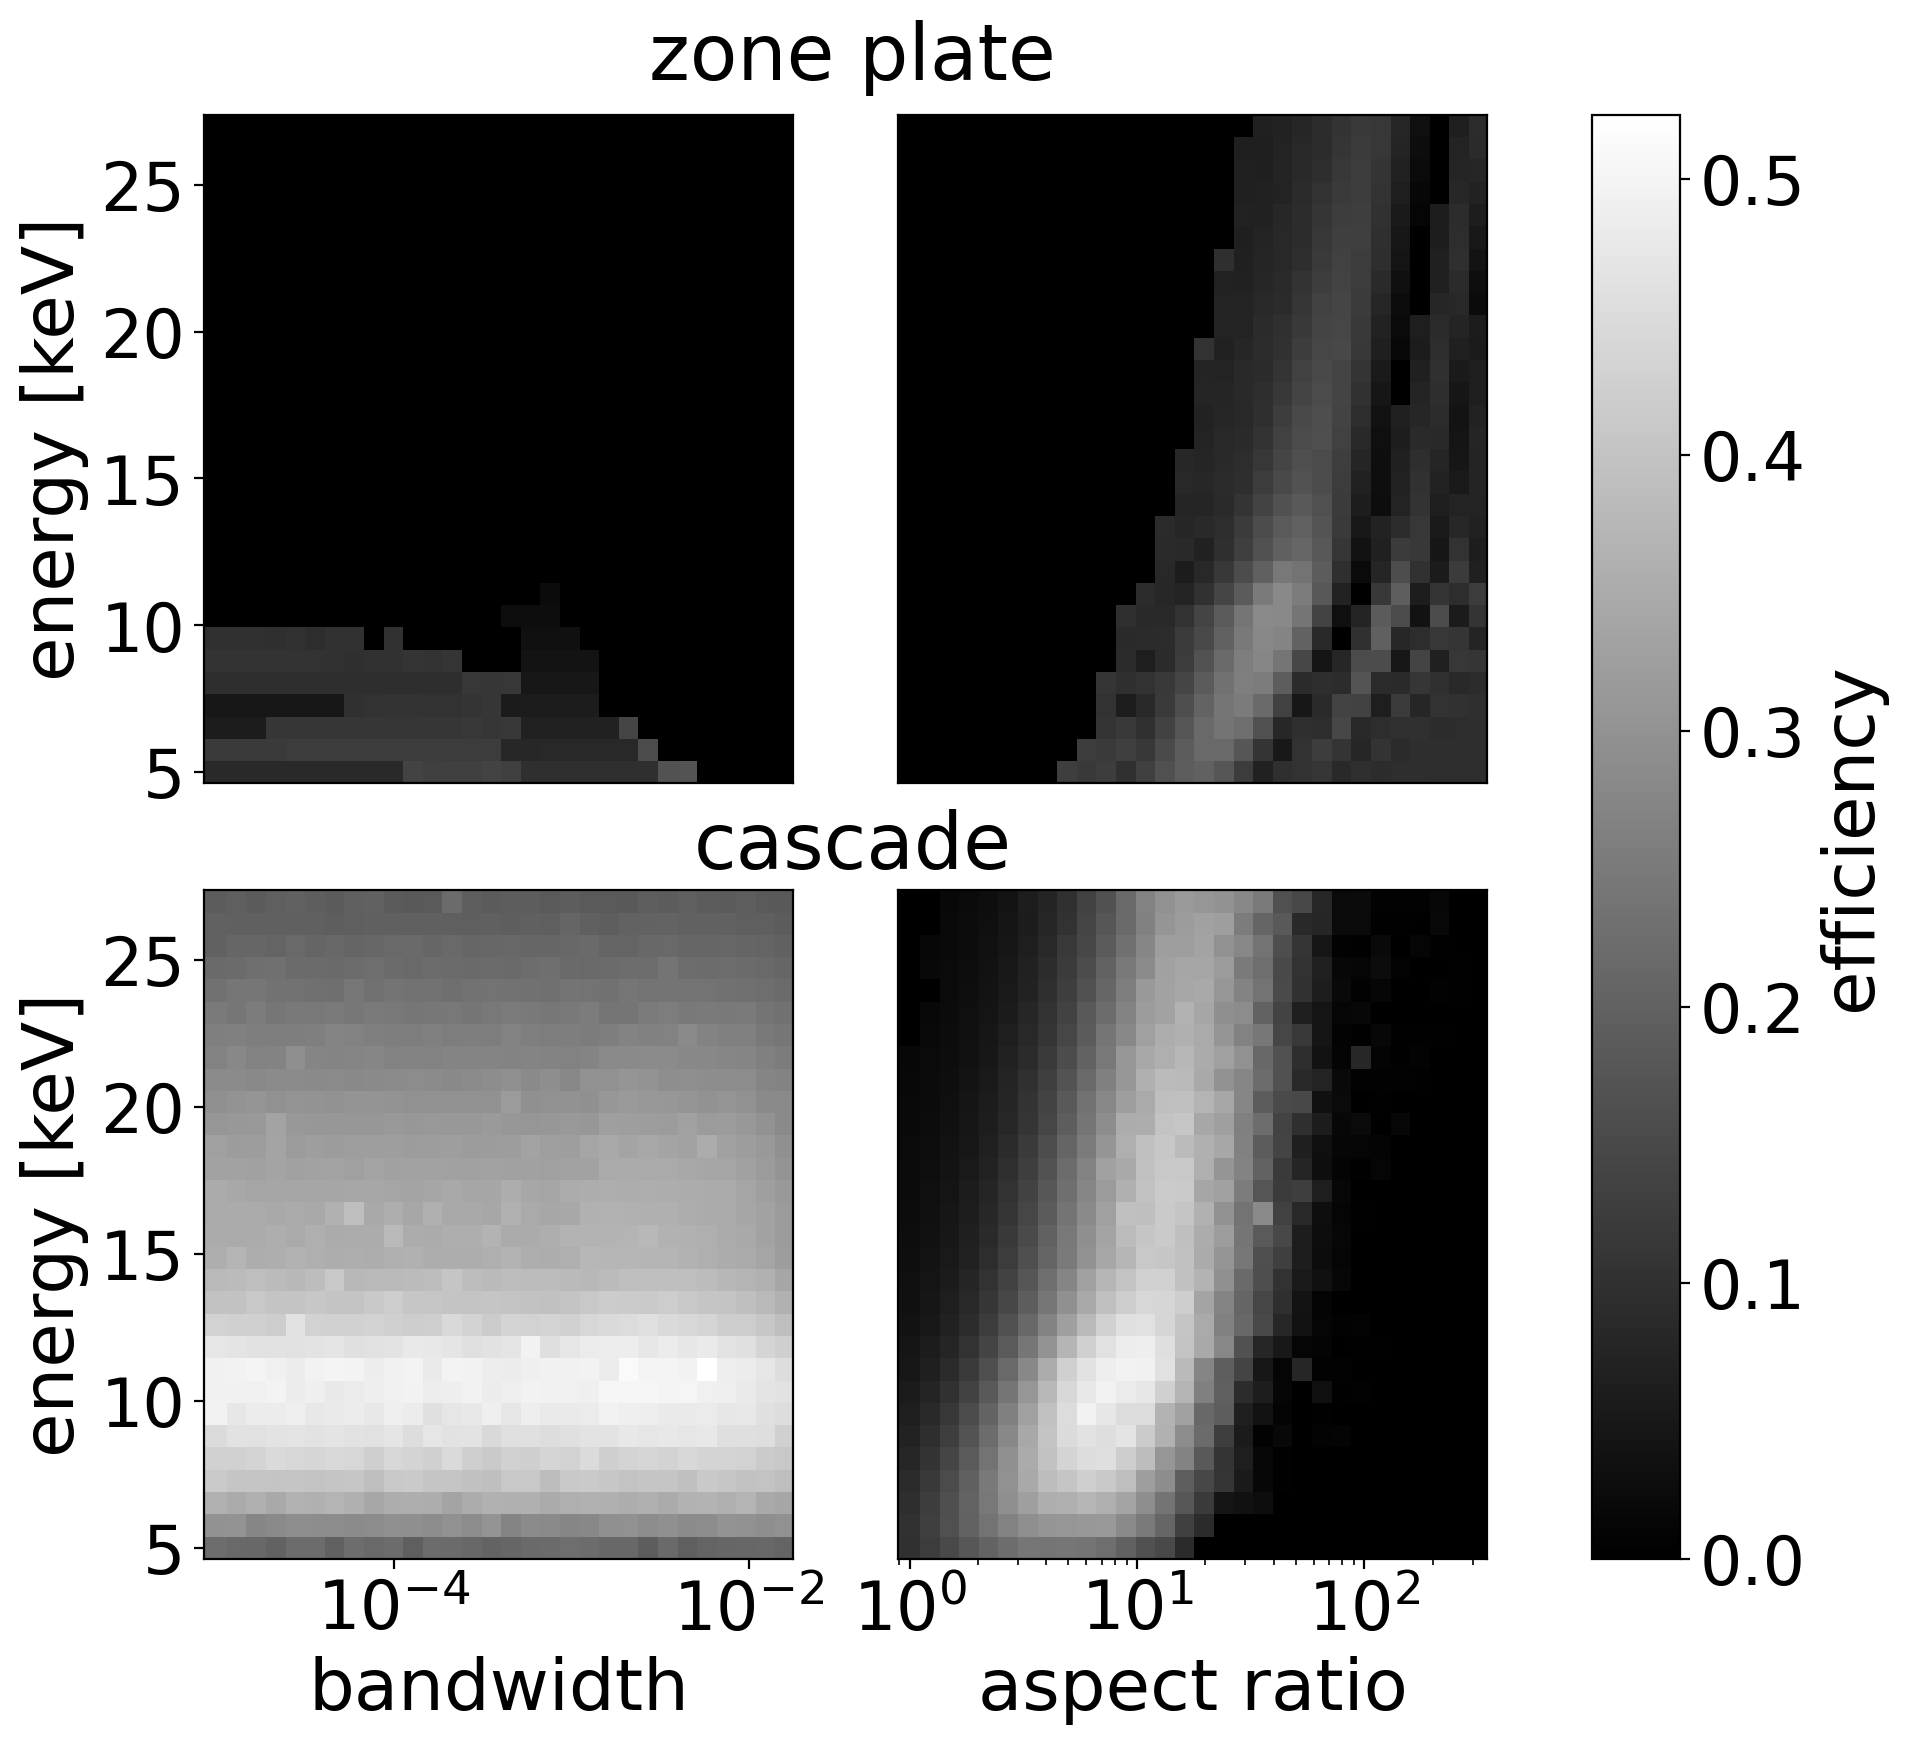

In [9]:
BW, E = np.meshgrid(bandwidths, energies/1e3)
T, E = np.meshgrid(thicknesses / ar_params['min_feature_size'], energies/1e3)

# 1. Setup Figure without 'compressed' layout
fig = plt.figure(figsize=(9, 9.5))

# 2. Define GridSpec
# 2 rows, 3 columns (Plot, Plot, Colorbar)
# width_ratios: Plots get weight 1, Colorbar gets tiny weight 0.05
# wspace/hspace: DIRECTLY control the gaps here.
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.15], 
                      wspace=0.25, hspace=0.16,
                      left=0.1, right=0.92, bottom=0.15, top=0.91)

# 3. Create Axes
ax_tl = fig.add_subplot(gs[0, 0]) # Top-Left
ax_tr = fig.add_subplot(gs[0, 1]) # Top-Right
ax_bl = fig.add_subplot(gs[1, 0]) # Bottom-Left
ax_br = fig.add_subplot(gs[1, 1]) # Bottom-Right
cax   = fig.add_subplot(gs[:, 2]) # Colorbar (spans both rows)

ax = np.array([[ax_tl, ax_tr], [ax_bl, ax_br]])

# 4. Plotting (Same as your code)
ax[0,0].pcolormesh(BW, E, bw_fzp_efficiencies, shading='auto', cmap='gray', vmin=0.0, vmax=max_eff)
im = ax[1,0].pcolormesh(BW, E, bw_opt_efficiencies, shading='auto', cmap='gray', vmin=0.0, vmax=max_eff)

ax[0,1].pcolormesh(T, E, ar_fzp_efficiencies, shading='auto', cmap='gray', vmin=0.0, vmax=max_eff)
im = ax[1,1].pcolormesh(T, E, ar_opt_efficiencies, shading='auto', cmap='gray', vmin=0.0, vmax=max_eff)

# 5. Row Titles
# Since we removed subfigures, we place these manually relative to the rows
# You might need to tweak the 'y' coordinate slightly
fig.text(0.46, 0.92, 'zone plate', fontsize=28, ha='center', va='bottom')
fig.text(0.46, 0.505, 'cascade', fontsize=28, ha='center', va='bottom')

# 6. Colorbar
cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=24)
cbar.set_label("efficiency", size=26)

# 7. Formatting (Same as your code)
for a in ax.flat:
    a.semilogx()
    a.tick_params(labelsize=24)

ax[1,0].set_xlabel("bandwidth", fontsize=26)
ax[0,0].set_ylabel("energy [keV]", fontsize=26)
ax[1,0].set_ylabel("energy [keV]", fontsize=26)
ax[1,1].set_xlabel("aspect ratio", fontsize=26)

ax[0,0].xaxis.set_visible(False)
ax[0,1].xaxis.set_visible(False)
ax[0,1].yaxis.set_visible(False)
ax[1,1].yaxis.set_visible(False)

plt.show()